# Ode to Joy, scored as a landscape

The inverse of `sound_of_paintings` (color -> sound): here the **score itself is the instruction**, not audio. No recording, no synthesis, no pitch-detection -- just the melody's own note data driving a picture directly, so there's no copyright question at all (the composition is public domain; we never touch a specific performance).

**Scope:** just the famous theme entrance from the finale of Beethoven's 9th -- the passage everyone knows, where the 16-bar tune is stated four times with Beethoven's own increasing orchestration: cello & bass alone (pp) -> + viola (p) -> + violin (mf) -> full orchestra (ff). That structure is exactly a landscape's depth cue (near/far) and a landscape's time-of-day cue (dark/bright), so the mapping fell out naturally:

- **Register -> terrain depth.** Bass is the ground you're standing on (nearest, present the whole time); violin is the farthest ridge (only visible once it enters). Each layer fades in continuously right as its instrument joins the score, rather than popping in panel-to-panel.
- **Dynamic (pp -> ff) -> a rising, brightening sun trail.** "Full orchestra" isn't one register, it's the climax -- so instead of another terrain band it becomes the sky itself warming from night-blue to sunrise-gold, with a trail of sun discs (like a long-exposure photo of the sun's path) tracking the crescendo across the whole width.
- **Melody pitch contour -> the mountain silhouette itself,** restated identically in all four sections since it's the same 16-bar tune each time -- only the sky and which layers are visible change.

The note sequence below was verified against two independent beginner-piano transcriptions (not just recalled from memory) before encoding, since the whole point of this piece is fidelity to the actual notes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

NOTE_SEMITONE = {"C": 0, "D": 2, "E": 4, "F": 5, "G": 7, "A": 9, "B": 11}

# the four 4-bar phrases of the theme, letter notes -- cross-checked against two
# independent published transcriptions rather than relied on from memory alone
LINE1 = "E E F G G F E D C C D E E D D".split()
LINE2 = "E E F G G F E D C C D E D C C".split()
LINE3 = "D D E C D E F E C D E F E D C D G".split()
LINE4 = LINE2
MELODY = LINE1 + LINE2 + LINE3 + LINE4

PITCH = np.array([NOTE_SEMITONE[n] for n in MELODY], dtype=float)
PITCH = (PITCH - PITCH.min()) / (PITCH.max() - PITCH.min())  # normalized 0..1 contour
len(MELODY), PITCH.round(2)

(62,
 array([0.57, 0.57, 0.71, 1.  , 1.  , 0.71, 0.57, 0.29, 0.  , 0.  , 0.29,
        0.57, 0.57, 0.29, 0.29, 0.57, 0.57, 0.71, 1.  , 1.  , 0.71, 0.57,
        0.29, 0.  , 0.  , 0.29, 0.57, 0.29, 0.  , 0.  , 0.29, 0.29, 0.57,
        0.  , 0.29, 0.57, 0.71, 0.57, 0.  , 0.29, 0.57, 0.71, 0.57, 0.29,
        0.  , 0.29, 1.  , 0.57, 0.57, 0.71, 1.  , 1.  , 0.71, 0.57, 0.29,
        0.  , 0.  , 0.29, 0.57, 0.29, 0.  , 0.  ]))

## The four variations and the terrain layers

Each variation is one full statement of the 16-bar tune. `dynamic` is Beethoven's own dynamic marking (pp/p/mf/ff) mapped to 0..1, driving the sky. Each terrain layer has a baseline height, an amplitude (how much the melody's pitch contour pushes it up), a color, and the x-position where that instrument first enters the score -- everything before that point smoothly collapses toward zero height instead of hard-cutting, so the whole thing reads as one continuous landscape rather than four stitched tiles.

In [2]:
VARIATIONS = [
    {"label": "Var. I — cello & bass alone, pp", "dynamic": 0.08},
    {"label": "Var. II — + viola, p",             "dynamic": 0.32},
    {"label": "Var. III — + violin, mf",          "dynamic": 0.60},
    {"label": "Var. IV — full orchestra, ff",     "dynamic": 1.00},
]
N_VAR = len(VARIATIONS)
CENTERS = np.arange(N_VAR) + 0.5
DYNAMICS = np.array([v["dynamic"] for v in VARIATIONS])

LAYER_STYLE = {
    "violin": dict(baseline=0.62, amp=0.16, color="#8fb8c9", enters_at=2.0),  # farthest, palest
    "viola":  dict(baseline=0.42, amp=0.20, color="#4f7a5c", enters_at=1.0),  # midground
    "bass":   dict(baseline=0.10, amp=0.22, color="#2a3b28", enters_at=0.0),  # nearest, darkest
}
LAYER_ORDER = ["violin", "viola", "bass"]  # draw far to near

SKY_COLD = np.array([0.09, 0.11, 0.22])   # night/dawn blue
SKY_WARM = np.array([1.00, 0.78, 0.35])   # sunrise gold
FADE_WIDTH = 0.5  # how gradually an instrument fades in around its entrance


def dynamic_at(x):
    return np.interp(x, CENTERS, DYNAMICS)


def smoothstep(x, edge0, edge1):
    t = np.clip((x - edge0) / (edge1 - edge0), 0, 1)
    return t * t * (3 - 2 * t)

## Render: sky, sun trail, terrain

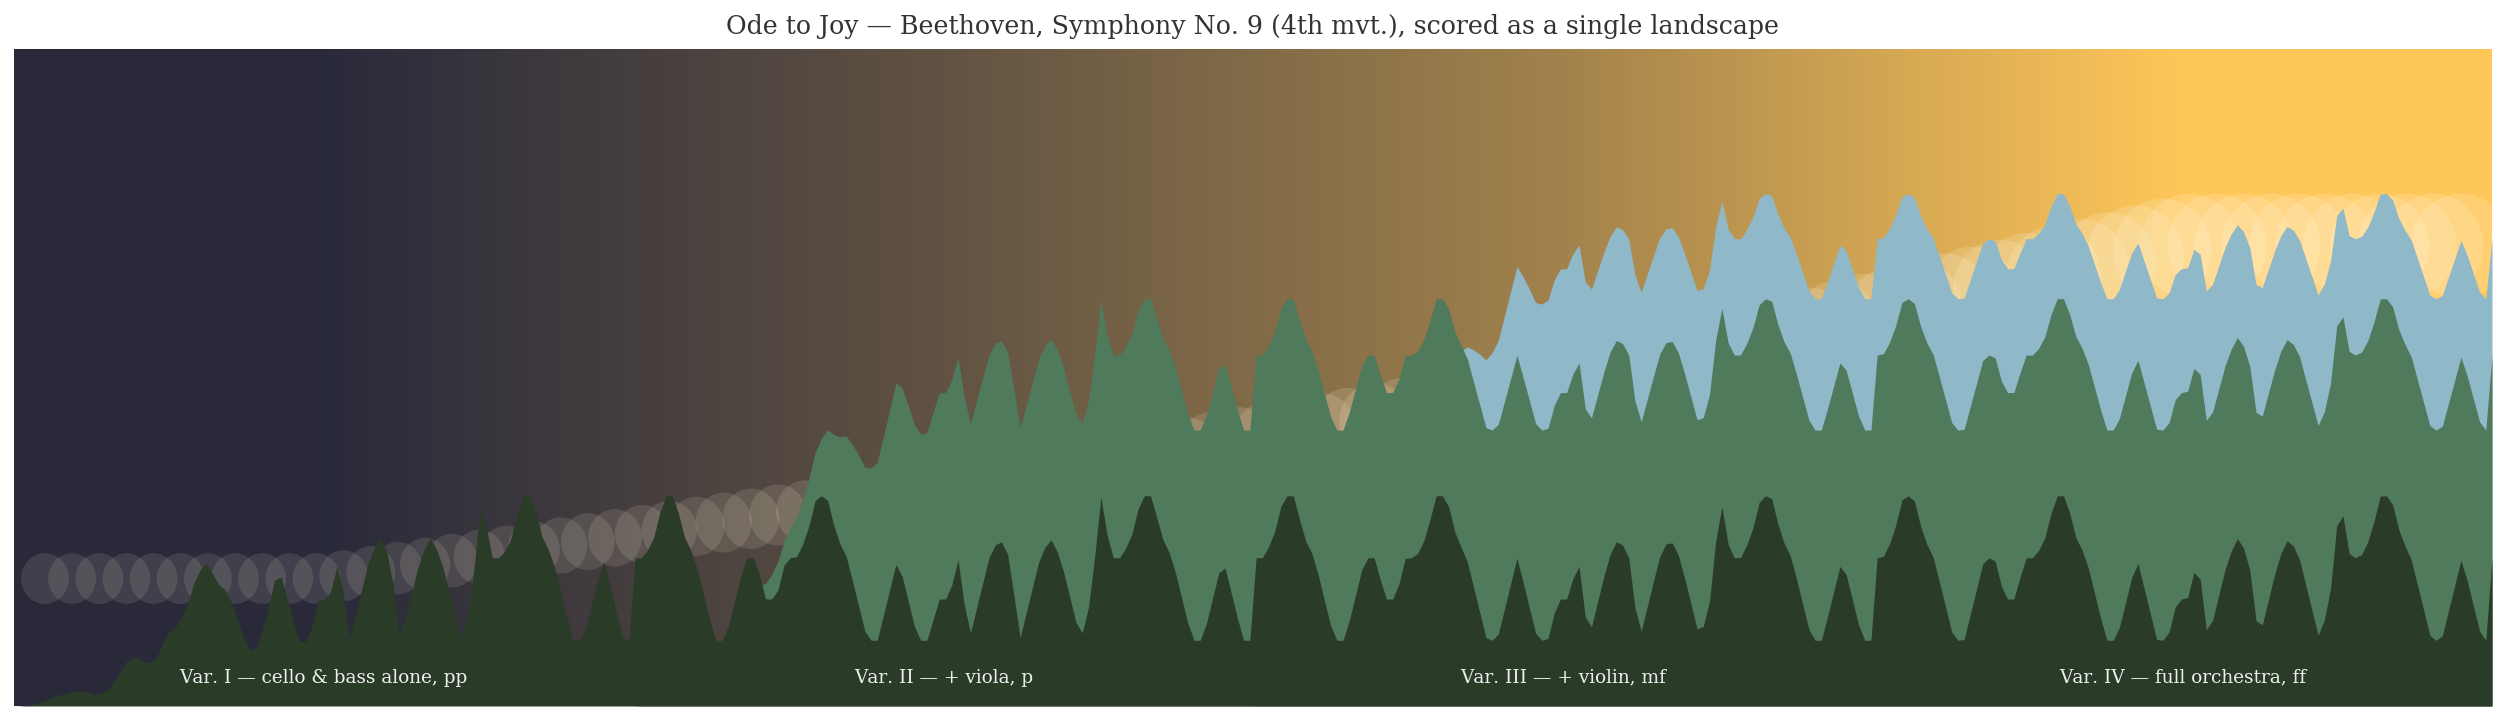

saved ode_to_joy_landscape.png


In [3]:
def draw_sky(ax):
    xs = np.linspace(0, N_VAR, 600)
    dyn = dynamic_at(xs)
    rgb = SKY_COLD[None, :] + (SKY_WARM - SKY_COLD)[None, :] * dyn[:, None]
    img = np.tile(rgb[None, :, :], (2, 1, 1))
    ax.imshow(img, extent=(0, N_VAR, 0, 1), origin="lower", aspect="auto", zorder=0)


def draw_sun_trail(ax, n_samples=90):
    xs = np.linspace(0.05, N_VAR - 0.05, n_samples)
    dyn = dynamic_at(xs)
    sun_y = 0.15 + 0.55 * dyn
    for x, y, d in zip(xs, sun_y, dyn):
        ax.add_patch(Circle((x, y), 0.035 + 0.045 * d, color="#fff6d8",
                             alpha=0.10 + 0.10 * d, zorder=1, linewidth=0))


def draw_terrain(ax, n_points=400):
    xs = np.linspace(0, N_VAR, n_points)
    melody_x = xs % 1.0  # same 16-bar tune restated once per variation
    contour = np.interp(melody_x, np.linspace(0, 1, len(PITCH)), PITCH)
    for name in LAYER_ORDER:
        style = LAYER_STYLE[name]
        presence = smoothstep(xs, style["enters_at"], style["enters_at"] + FADE_WIDTH)
        ys = presence * (style["baseline"] + style["amp"] * contour)
        ax.fill_between(xs, 0, ys, color=style["color"], zorder=10 + LAYER_ORDER.index(name), linewidth=0)


def render(out_path="ode_to_joy_landscape.png"):
    fig, ax = plt.subplots(figsize=(18, 5.2), dpi=140)
    draw_sky(ax)
    draw_sun_trail(ax)
    draw_terrain(ax)
    for v, cx in zip(VARIATIONS, CENTERS):
        ax.text(cx, 0.03, v["label"], ha="center", va="bottom", fontsize=9.5,
                color="white", zorder=50, fontfamily="serif", alpha=0.92)
    ax.set_xlim(0, N_VAR)
    ax.set_ylim(0, 1)
    ax.axis("off")
    fig.suptitle("Ode to Joy — Beethoven, Symphony No. 9 (4th mvt.), scored as a single landscape",
                 fontsize=13, color="#333333", y=0.98, fontfamily="serif")
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    fig.savefig(out_path, facecolor="white")
    plt.show()
    print(f"saved {out_path}")

render()

## Takeaways

- No audio anywhere in this pipeline -- score data (pitch, dynamic marking, instrument entrance) drives the picture directly. That sidesteps every pitch-detection/copyright issue that a real-audio approach would carry.
- The "landscape" framing wasn't forced: Beethoven's own four-variation orchestration already has a near/far depth structure (which instrument enters when) and a quiet/loud energy arc that map onto landscape depth and time-of-day almost without translation.
- Continuous fade-ins (via `smoothstep` collapsing each layer toward zero height before its entrance) were the fix for the first draft, which rendered as four visibly stitched panels instead of one landscape -- matches the same lesson as `feedback_sonification_design`: discrete per-segment parameters read as seams unless smoothed into a continuous curve.